In [1]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import roc_curve, auc




In [38]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2


In [39]:
class CAMDenseNet(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.densenet121(pretrained=False)
        self.features = base.features

        self.classifier = nn.Linear(1024, 2)

        self.seg_head = nn.Sequential(
            nn.Conv2d(1024, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 1, 1)
        )

    def forward(self, x):
        feat = self.features(x)
        feat = F.relu(feat)

        pooled = F.adaptive_avg_pool2d(feat, 1).view(feat.size(0), -1)
        logits = self.classifier(pooled)

        seg_map = self.seg_head(feat)
        seg_map = F.interpolate(seg_map, size=x.shape[2:], mode="bilinear")

        return logits, seg_map, feat


In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CAMDenseNet().to(device)
model.load_state_dict(torch.load("cam_multitask_densenet_ksdd.pth", map_location=device))
model.eval()

print("Model loaded successfully.")


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully.


In [41]:
DATA_ROOT = "KolektorSDD-boxes"

image_paths = []
mask_paths = []

for kos_folder in sorted(os.listdir(DATA_ROOT)):
    kos_path = os.path.join(DATA_ROOT, kos_folder)

    if os.path.isdir(kos_path):
        images = glob(os.path.join(kos_path, "*.jpg"))

        for img_path in images:
            mask_path = img_path.replace(".jpg", "_label.bmp")

            if os.path.exists(mask_path):
                image_paths.append(img_path)
                mask_paths.append(mask_path)

print("Total samples:", len(image_paths))


Total samples: 399


In [42]:
from sklearn.model_selection import train_test_split

_, val_imgs, _, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


In [43]:
class KSDDDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx], 0)

        label = 1 if mask.sum() > 0 else 0

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0).float() / 255.0

        return image, mask, torch.tensor(label).long()


In [44]:
val_tfms = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])


In [45]:
val_dataset = KSDDDataset(val_imgs, val_masks, val_tfms)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Validation loader ready.")


Validation loader ready.


In [46]:
def dice_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)


In [47]:
results = evaluate_model(model, val_loader)


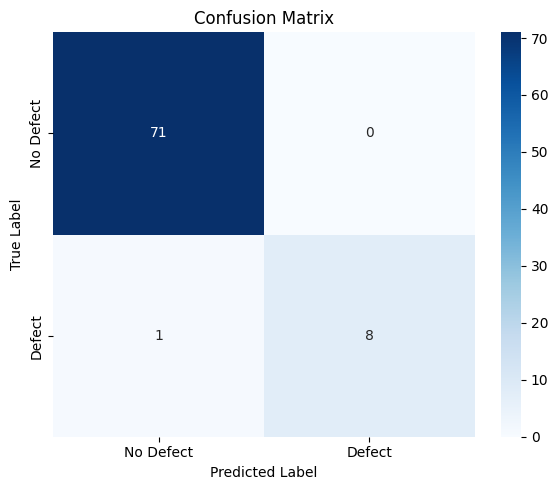

In [48]:
cm = results["confusion_matrix"]

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Defect", "Defect"],
            yticklabels=["No Defect", "Defect"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [49]:
print("===== Classification Metrics =====")
print("Accuracy:", results["accuracy"])
print("Precision:", results["precision"])
print("Recall:", results["recall"])
print("F1 Score:", results["f1_score"])

print("\n===== Segmentation Metrics =====")
print("Dice Score:", results["dice_score"])
print("IoU Score:", results["iou_score"])
print("Pixel Accuracy:", results["pixel_accuracy"])


===== Classification Metrics =====
Accuracy: 0.9875
Precision: 1.0
Recall: 0.8888888888888888
F1 Score: 0.9411764705882353

===== Segmentation Metrics =====
Dice Score: 0.8875000000743786
IoU Score: 0.8875000000743786
Pixel Accuracy: 0.9971614837646484


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
from sklearn.metrics import roc_curve, auc


In [55]:
def visualize_cam_overlay(model, loader):
    model.eval()

    images, masks, labels = next(iter(loader))
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        logits, seg_pred, features = model(images)

    weight = model.classifier.weight
    cams = []

    for i in range(images.size(0)):
        class_idx = labels[i]
        cam = torch.sum(weight[class_idx][:, None, None] * features[i], dim=0)
        cam = torch.relu(cam)
        cam = (cam - cam.min()) / (cam.max() + 1e-6)

        cams.append(cam.detach().cpu().numpy())  # 🔥 FIXED

    cam = cams[0]

    cam = cv2.resize(cam, (256, 256))

    img = images[0].detach().cpu().permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = 0.6 * img + 0.4 * heatmap

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap="jet")
    plt.title("CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("CAM Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()



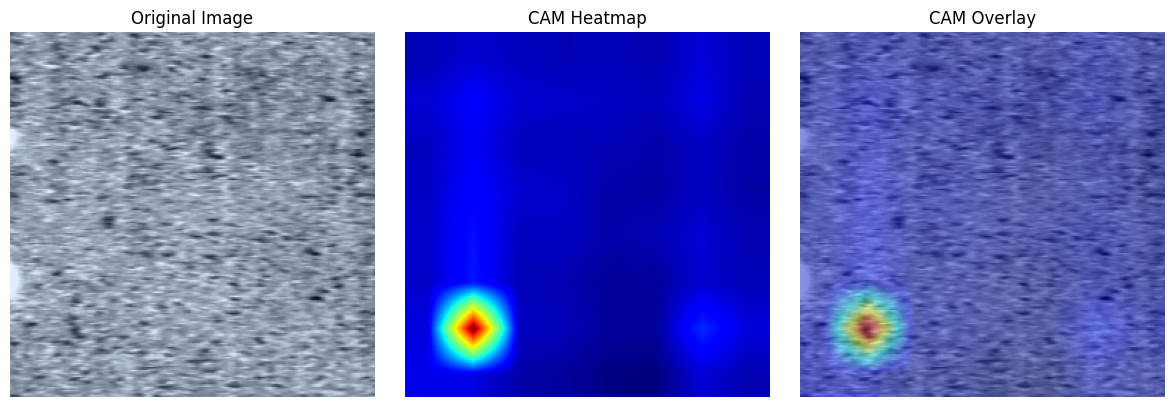

In [56]:
visualize_cam_overlay(model, val_loader)


In [70]:
def visualize_classification(model, loader, num_samples=5):
    model.eval()

    images, masks, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        logits, _, _ = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

    plt.figure(figsize=(15,5))

    for i in range(num_samples):
        img = images[i].cpu().permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        true_label = labels[i].item()
        pred_label = preds[i].cpu().item()
        confidence = probs[i][pred_label].cpu().item()

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


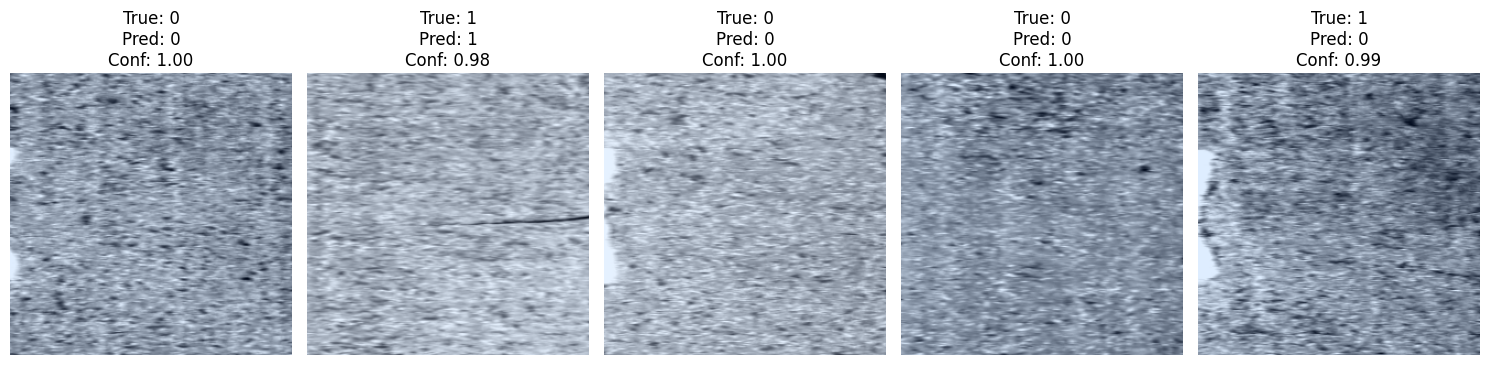

In [71]:
visualize_classification(model, val_loader, num_samples=5)


In [78]:
def visualize_segmentation_soft(model, loader, threshold=0.2):
    model.eval()

    for images, masks, labels in loader:
        for i in range(len(labels)):

            if labels[i] == 1:  # Only defect samples

                image = images[i].unsqueeze(0).to(device)
                gt_mask = masks[i]

                with torch.no_grad():
                    _, seg_pred, _ = model(image)

                seg_prob = torch.sigmoid(seg_pred)
                prob_map = seg_prob[0].cpu().squeeze().numpy()

                # Lower threshold to capture weak predictions
                seg_binary = (seg_prob > threshold).float()
                pred_mask = seg_binary[0].cpu().squeeze().numpy()

                img = image[0].cpu().permute(1,2,0).numpy()
                img = (img - img.min()) / (img.max() - img.min())

                gt = gt_mask.squeeze().numpy()

                # Overlay prediction
                overlay = img.copy()
                overlay[pred_mask == 1] = [1, 0, 0]  # red overlay

                plt.figure(figsize=(16,4))

                plt.subplot(1,4,1)
                plt.imshow(img)
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(1,4,2)
                plt.imshow(gt, cmap="gray")
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1,4,3)
                plt.imshow(prob_map, cmap="jet")
                plt.title("Probability Map")
                plt.axis("off")

                plt.subplot(1,4,4)
                plt.imshow(overlay)
                plt.title(f"Binary Mask (thr={threshold})")
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                return


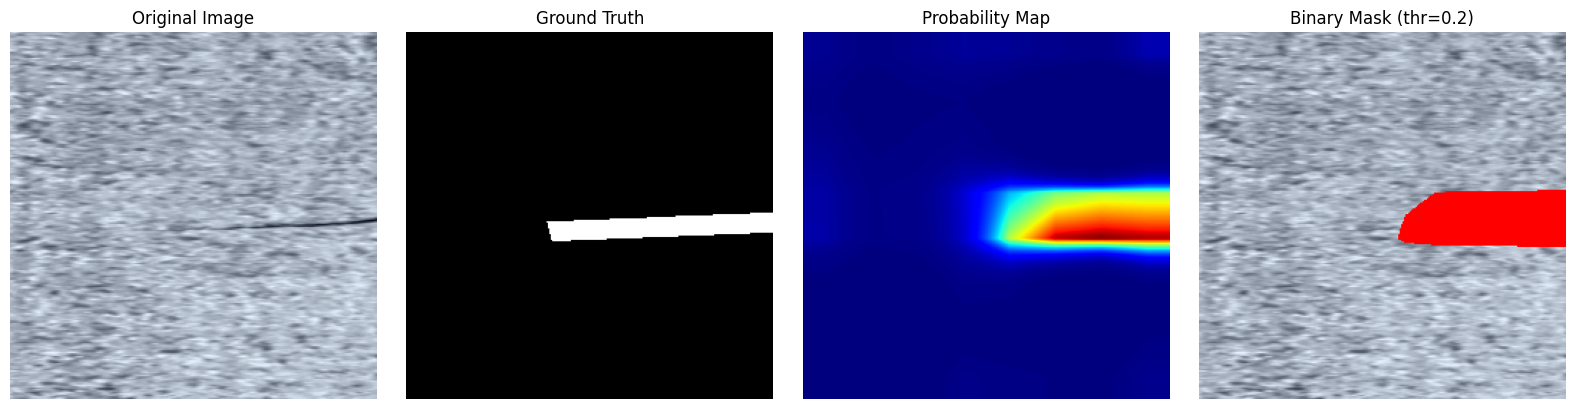

In [80]:
visualize_segmentation_soft(model, val_loader, threshold=0.2)



In [81]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, masks, labels in loader:
            images = images.to(device)

            logits, _, _ = model(images)
            probs = torch.softmax(logits, dim=1)[:,1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    print("AUC Score:", roc_auc)


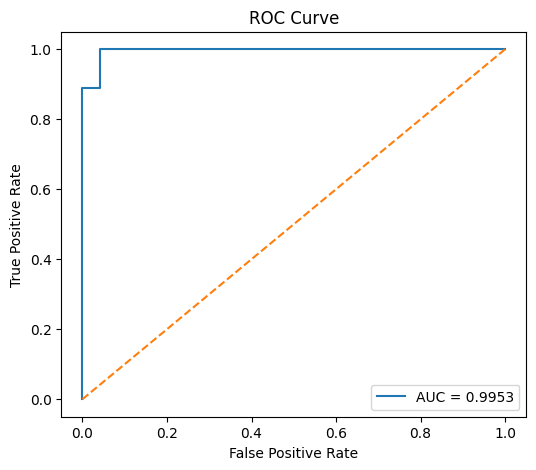

AUC Score: 0.9953051643192489


In [82]:
plot_roc_curve(model, val_loader)
